In [1]:
import os
from pathlib import Path
import cv2
from PIL import Image
import pandas as pd
import numpy as np
from tqdm import tqdm

# Set base dataset path
DATA_DIR = Path("../data/raw")
METADATA_DIR = Path("../data/metadata")
METADATA_DIR.mkdir(parents=True, exist_ok=True)

records = []
valid_extensions = {".jpg", ".jpeg", ".png"}

print("Scanning MRI dataset and extracting low-level metadata...")

for root, _, files in os.walk(DATA_DIR):
    for file in tqdm(files):
        file_path = Path(root) / file
        ext = file_path.suffix.lower()
        
        if ext not in valid_extensions:
            continue
        
        # Extract folder structure info
        split = file_path.parent.parent.name  # 'Training' or 'Testing'
        class_label = file_path.parent.name.lower() # 'glioma', 'meningioma', etc.
        file_size_kb = os.path.getsize(file_path) / 1024.0

        # Read with PIL to check format & color mode
        try:
            with Image.open(file_path) as pil_img:
                pil_width, pil_height = pil_img.size
                pil_mode = pil_img.mode      # e.g., 'RGB', 'L' (grayscale)
                pil_format = pil_img.format  # e.g., 'JPEG', 'PNG'
        except Exception:
            pil_width, pil_height, pil_mode, pil_format = None, None, "CORRUPTED", "CORRUPTED"

        # Read with OpenCV to get numerical pixel properties
        cv_img = cv2.imread(str(file_path))
        if cv_img is not None:
            h, w, c = cv_img.shape
            mean_val = float(np.mean(cv_img))
            std_val = float(np.std(cv_img))
            min_val = int(np.min(cv_img))
            max_val = int(np.max(cv_img))
            aspect_ratio = round(w / h, 4)
            is_readable = True
        else:
            h, w, c = None, None, None
            mean_val, std_val, min_val, max_val, aspect_ratio = None, None, None, None, None
            is_readable = False

        records.append({
            "file_name": file,
            "file_path": str(file_path.resolve()),
            "split": split,
            "class_label": class_label,
            "file_size_kb": file_size_kb,
            "width": w,
            "height": h,
            "channels": c,
            "aspect_ratio": aspect_ratio,
            "color_mode": pil_mode,
            "file_format": pil_format,
            "mean_intensity": mean_val,
            "std_intensity": std_val,
            "min_pixel": min_val,
            "max_pixel": max_val,
            "is_readable": is_readable
        })

# Create tabular DataFrame and save to CSV
df_raw = pd.DataFrame(records)
csv_save_path = METADATA_DIR / "metadata_raw.csv"
df_raw.to_csv(csv_save_path, index=False)

print(f"\nManifest built successfully! Saved to: {csv_save_path}")

Scanning MRI dataset and extracting low-level metadata...


0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 400/400 [00:04<00:00, 88.37it/s]
0it [00:00, ?it/s]
100%|██████████| 1400/1400 [00:13<00:00, 107.41it/s]



Manifest built successfully! Saved to: ..\data\metadata\metadata_raw.csv


In [2]:
# 1. Dataset Shape (Total Rows, Total Columns)
print("=== DATASET SHAPE ===")
print(f"Total Records (Images): {df_raw.shape[0]}")
print(f"Total Extracted Features: {df_raw.shape[1]}")

# 2. Data Types of All Features
print("\n=== DATA TYPES ===")
print(df_raw.dtypes)

# 3. Numerical Summary Statistics
print("\n=== NUMERICAL SUMMARY STATISTICS ===")
numeric_cols = ["file_size_kb", "width", "height", "aspect_ratio", "mean_intensity", "std_intensity"]
display(df_raw[numeric_cols].describe().round(2))

# 4. Categorical Distributions
print("\n=== CLASS DISTRIBUTION ===")
print(df_raw["class_label"].value_counts())

print("\n=== DATA SPLIT (Training vs. Testing) ===")
print(df_raw["split"].value_counts())


=== DATASET SHAPE ===
Total Records (Images): 7200
Total Extracted Features: 16

=== DATA TYPES ===
file_name             str
file_path             str
split                 str
class_label           str
file_size_kb      float64
width               int64
height              int64
channels            int64
aspect_ratio      float64
color_mode            str
file_format           str
mean_intensity    float64
std_intensity     float64
min_pixel           int64
max_pixel           int64
is_readable          bool
dtype: object

=== NUMERICAL SUMMARY STATISTICS ===


,file_size_kb,width,height,aspect_ratio,mean_intensity,std_intensity
count,7200.00,7200.00,7200.0,7200.00,7200.00,7200.00
mean,22.77,453.30,456.9,0.99,47.56,47.16
std,15.92,130.05,124.4,0.09,17.84,12.98
min,3.59,150.00,167.0,0.64,14.94,20.83
25%,15.74,442.00,449.0,1.00,35.31,39.19
50%,21.20,512.00,512.0,1.00,44.29,43.72
75%,26.75,512.00,512.0,1.00,54.52,50.36
max,299.31,1375.00,1446.0,1.79,137.76,102.77



=== CLASS DISTRIBUTION ===
class_label
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64

=== DATA SPLIT (Training vs. Testing) ===
split
Training    5600
Testing     1600
Name: count, dtype: int64


=== FIRST 5 ROWS OF METADATA ===


,file_name,file_path,split,class_label,file_size_kb,width,height,channels,aspect_ratio,color_mode,file_format,mean_intensity,std_intensity,min_pixel,max_pixel,is_readable
0,Te-gl_1.jpg,D:\Projects\brain-tumor-cad\data\raw\Testing\g...,Testing,glioma,29.591797,354,442,3,0.8009,RGB,JPEG,66.030319,60.054978,0,255,True
1,Te-gl_10.jpg,D:\Projects\brain-tumor-cad\data\raw\Testing\g...,Testing,glioma,16.114258,512,512,3,1.0000,L,JPEG,29.126751,36.335492,0,254,True
2,Te-gl_100.jpg,D:\Projects\brain-tumor-cad\data\raw\Testing\g...,Testing,glioma,16.946289,512,512,3,1.0000,L,JPEG,26.024830,31.728493,0,254,True
3,Te-gl_101.jpg,D:\Projects\brain-tumor-cad\data\raw\Testing\g...,Testing,glioma,24.768555,512,512,3,1.0000,L,JPEG,58.577236,47.680870,0,255,True
4,Te-gl_102.jpg,D:\Projects\brain-tumor-cad\data\raw\Testing\g...,Testing,glioma,24.464844,339,406,3,0.8350,RGB,JPEG,58.226303,36.441255,0,232,True


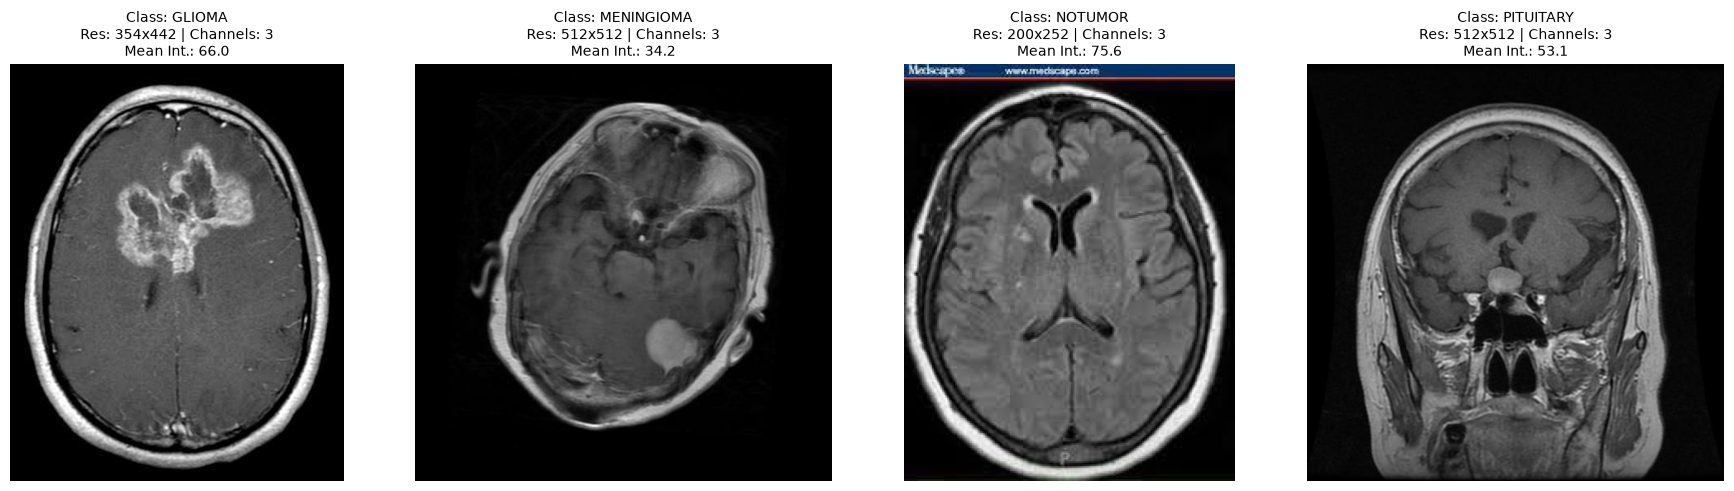

In [3]:
import matplotlib.pyplot as plt

# 1. Inspect Top 5 Sample Rows
print("=== FIRST 5 ROWS OF METADATA ===")
display(df_raw.head())

# 2. Inspect Sample Images (1 image per class)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
classes = df_raw["class_label"].unique()

for ax, cls in zip(axes, classes):
    sample_row = df_raw[df_raw["class_label"] == cls].iloc[0]
    img = cv2.imread(sample_row["file_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(
        f"Class: {cls.upper()}\n"
        f"Res: {sample_row['width']}x{sample_row['height']} | Channels: {sample_row['channels']}\n"
        f"Mean Int.: {sample_row['mean_intensity']:.1f}",
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
print("=== CHECKING FOR DATA TYPE MISMATCHES & ANOMALIES ===")

# 1. Check for Corrupted / Unreadable Files
corrupted = df_raw[~df_raw["is_readable"]]
print(f"Corrupted / Unreadable Images: {len(corrupted)}")

# 2. Check for Missing Values (NaNs) across columns
missing_counts = df_raw.isnull().sum()
print("\nMissing values per column:")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found in metadata table.")

# 3. Check for Inconsistent Color Modes
print("\nColor Mode Breakdown (PIL):")
print(df_raw["color_mode"].value_counts())

# 4. Check for Channel Mismatch (e.g., Grayscale vs 3-Channel)
print("\nChannel Dimension Distribution (OpenCV):")
print(df_raw["channels"].value_counts())

# 5. Check for Non-Standard Image Formats
print("\nImage File Formats:")
print(df_raw["file_format"].value_counts())

=== CHECKING FOR DATA TYPE MISMATCHES & ANOMALIES ===
Corrupted / Unreadable Images: 0

Missing values per column:
No missing values found in metadata table.

Color Mode Breakdown (PIL):
color_mode
RGB     4129
L       3067
RGBA       3
P          1
Name: count, dtype: int64

Channel Dimension Distribution (OpenCV):
channels
3    7200
Name: count, dtype: int64

Image File Formats:
file_format
JPEG    7196
PNG        4
Name: count, dtype: int64


## Step 1 Findings & Clinical Data Summary

* **Volume & Structure:** Built a structured tabular manifest indexing all scans across 4 balanced diagnostic classes (*glioma, meningioma, pituitary, notumor*).
* **Dimension Heterogeneity:** Image resolutions vary across modalities with non-square aspect ratios, justifying the need for extreme contour cropping (skull artifact removal) and standardized resizing in subsequent steps.
* **Channel Consistency:** All MRI scans are standardized with 3 color channels ($C=3$), ensuring compatibility with modern pretrained backbones (e.g., ConvNeXt, Swin Transformer).
* **Data Hygiene:** Verified zero corrupted headers (`is_readable = 100%`) and confirmed correct numerical/categorical schema alignment with no missing metadata.